In [4]:
import pandas as pd
df=pd.read_csv("gapminder.csv")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [4]:
df.isnull().sum()

country      0
continent    0
year         0
lifeExp      0
pop          0
gdpPercap    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

country       object
continent     object
year           int64
lifeExp      float64
pop            int64
gdpPercap    float64
dtype: object

In [7]:
df.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [9]:
# Questions:
# 1. How at what rate is India's population growing over time? (form an equation)
# 2. What is the correlation between GDP per capita and life expectancy?
# 3. Rank countries by GDP per capita from 2007. Select the top 3.
# 4. How has life expectancy in the US changed over time?
# 5. Which countries changed most between 1952 and 2007?

In [9]:
# Q1
India_data=df[df["country"] =="India"]
India_pop=India_data.groupby("year")["pop"].mean()
India_pop

year
1952    3.720000e+08
1957    4.090000e+08
1962    4.540000e+08
1967    5.060000e+08
1972    5.670000e+08
1977    6.340000e+08
1982    7.080000e+08
1987    7.880000e+08
1992    8.720000e+08
1997    9.590000e+08
2002    1.034173e+09
2007    1.110396e+09
Name: pop, dtype: float64

In [10]:
# Q2

correlation = df["gdpPercap"].corr(df["lifeExp"])
correlation

np.float64(0.5837062198659803)

In [20]:
# Q3
data_2007=df[df["year"]== 2007]
rank=data_2007.sort_values("gdpPercap", ascending=False).head(3)
rank

,country,continent,year,lifeExp,pop,gdpPercap
1151,Norway,Europe,2007,80.196,4627926,49357.19017
863,Kuwait,Asia,2007,77.588,2505559,47306.98978
1367,Singapore,Asia,2007,79.972,4553009,47143.17964


In [17]:
# Q4

US_data.groupby("year")["lifeExp"].mean()

year
1952    37.373
1957    40.249
1962    43.605
1967    47.193
1972    50.651
1977    54.208
1982    56.596
1987    58.553
1992    60.223
1997    61.765
2002    62.879
2007    64.698
Name: lifeExp, dtype: float64

<Axes: xlabel='year'>

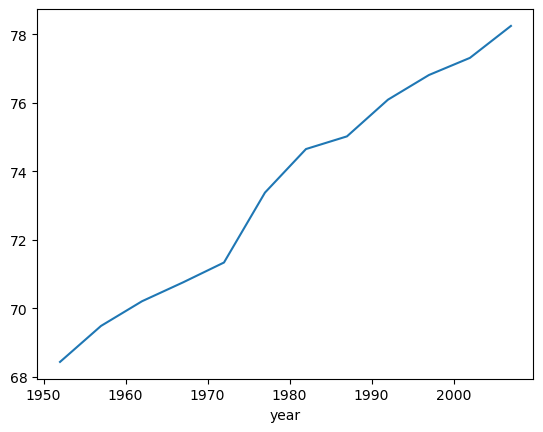

In [18]:
US_data.groupby("year")["lifeExp"].mean().plot()

In [21]:
# Q5

data_1952 = df[df["year"] == 1952]
data_2007 = df[df["year"] == 2007]

comparison = data_1952.merge(data_2007, on="country", suffixes=("_1952", "_2007"))
comparison["lifeExp_change"] = comparison["lifeExp_2007"] - comparison["lifeExp_1952"]

comparison.sort_values("lifeExp_change", ascending=False).head(10)

,country,continent_1952,year_1952,lifeExp_1952,pop_1952,gdpPercap_1952,continent_2007,year_2007,lifeExp_2007,pop_2007,gdpPercap_2007,lifeExp_change
96,Oman,Asia,1952,37.578,507833,1828.230307,Asia,2007,75.640,3204897,22316.192870,38.062
137,Vietnam,Asia,1952,40.412,26246839,605.066492,Asia,2007,74.249,85262356,2441.576404,33.837
59,Indonesia,Asia,1952,37.468,82052000,749.681655,Asia,2007,70.650,223547000,3540.651564,33.182
109,Saudi Arabia,Asia,1952,39.875,4005677,6459.554823,Asia,2007,72.777,27601038,21654.831940,32.902
75,Libya,Africa,1952,42.723,1019729,2387.548060,Africa,2007,73.952,6036914,12057.499280,31.229
70,"Korea, Rep.",Asia,1952,47.453,20947571,1030.592226,Asia,2007,78.623,49044790,23348.139730,31.170
92,Nicaragua,Americas,1952,42.314,1165790,3112.363948,Americas,2007,72.899,5675356,2749.320965,30.585
138,West Bank and Gaza,Asia,1952,43.160,1030585,1515.592329,Asia,2007,73.422,4018332,3025.349798,30.262
139,"Yemen, Rep.",Asia,1952,32.548,4963829,781.717576,Asia,2007,62.698,22211743,2280.769906,30.150
46,Gambia,Africa,1952,30.000,284320,485.230659,Africa,2007,59.448,1688359,752.749726,29.448
